**PREVISÃO DE SÉRIES TEMPORAIS COM O USO DE FOUNDATION MODELS**



> “A foundation model is itself incomplete but serves as the common basis from which many task-specific models are built via adaptation. We also chose the term ‘foundation’ to connote the significance of architectural stability, safety and security: poorly constructed foundations are a recipe for disaster and well-executed foundations are a reliable bedrock for future applications.”

In [ ]:
%pip install sktime

In [ ]:
import pandas as pd
import torch
import sktime
import numpy as np
import matplotlib.pyplot as plt
from transformers import PatchTSMixerConfig, PatchTSMixerForPrediction
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError, MeanAbsoluteError, MeanSquaredError
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error,  mean_absolute_error
from sktime.forecasting.model_selection import temporal_train_test_split

Séries temporais a serem analisadas:
1) US Births - que registra os nascimentos ocorridos por dia nos EUA ao longo dos anos de 1969 a 1988;
2) Saugeen River Flow - que registra o fluxo do Rio Saugeen em metros cúbicos por segundo por dia de 1915 a 1979;
3) Sunspot - registra o número de manchas solares registradas por dia de 1818-01-08 até 2020-05-31. ;
4) Traffic Weekly - conta com registros das taxas de ocupação das rodovias de San Francisco de 2015 a 2016;
5) Tourism Mounthly - registro de taxas de turismo mensais em uma localidade.

Algumas desses datasets contam com diversas séries. Para fins de padronização, usamos uma série por dataset.

CARREGAMENTO DOS DATASETS:

1) US Births:

Series size: 7305


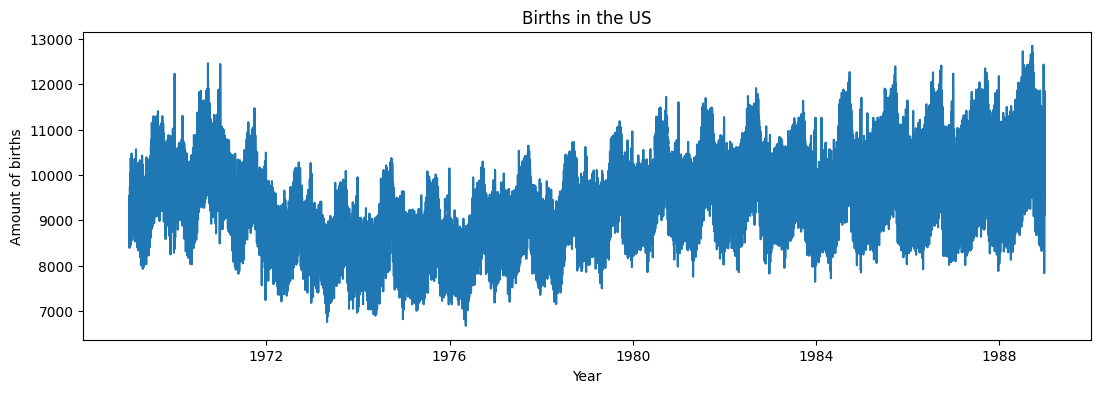

In [ ]:
df1 = pd.read_csv(
    "/content/us_births_dataset.tsf",
    sep="\t",
    header=None,
    skiprows=15
)

series_raw = df1.iloc[0, 0]

# captura apenas o que está escrito após "T1:1969-01-01 00-00-00:", separa por
# vírgula e converte para inteiro
parts = series_raw.split(":")
valuesstr = parts[2]
values = valuesstr.split(",")
values = pd.to_numeric(values)

# converte a lista para a estrutura Series
y1 = pd.Series(values)

# ordena os valores por data a partir de 01/01/1969
y1.index = pd.date_range(
    start="1969-01-01",
    periods=len(y1),
    freq="D"
)


print(f'Series size: {len(y1)}')
plt.figure(figsize=(13,4))
plt.plot(y1)
plt.title("Births in the US")
plt.xlabel("Year")
plt.ylabel("Amount of births")
plt.show()

2. Saugeen River Flow:

Series size: 23741


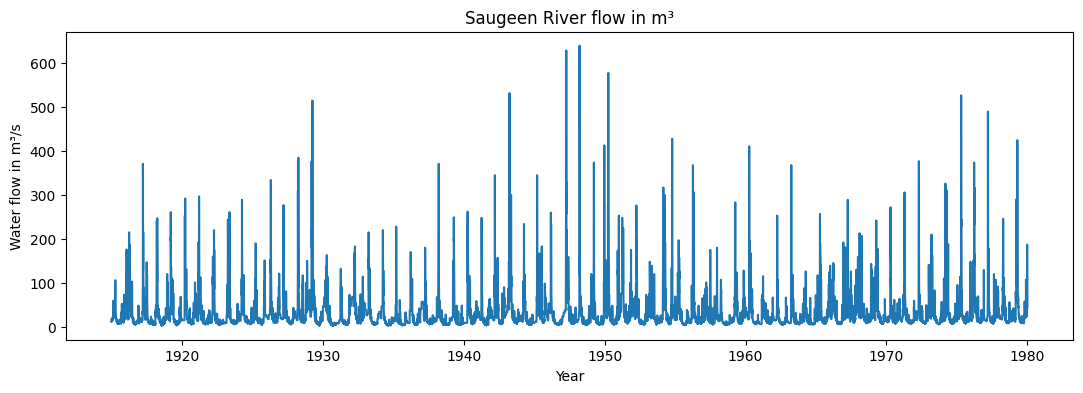

In [ ]:
df2 = pd.read_csv(
    "/content/saugeenday_dataset.tsf",
    sep="\t",
    header=None,
    skiprows=16
)

series_raw = df2.iloc[0, 0]

parts = series_raw.split(":")
valuesstr = parts[2]
values = valuesstr.split(",")
values = pd.to_numeric(values)

# converte a lista para a estrutura Series
y2 = pd.Series(values)

# ordena os valores por data a partir de 01/01/1969
y2.index = pd.date_range(
    start="1915-01-01",
    periods=len(y2),
    freq="D"
)

print(f'Series size: {len(y2)}')
plt.figure(figsize=(13,4))
plt.plot(y2)
plt.title("Saugeen River flow in m³")
plt.xlabel("Year")
plt.ylabel("Water flow in m³/s")
plt.show()

3) Sunspot

Series size: 73924


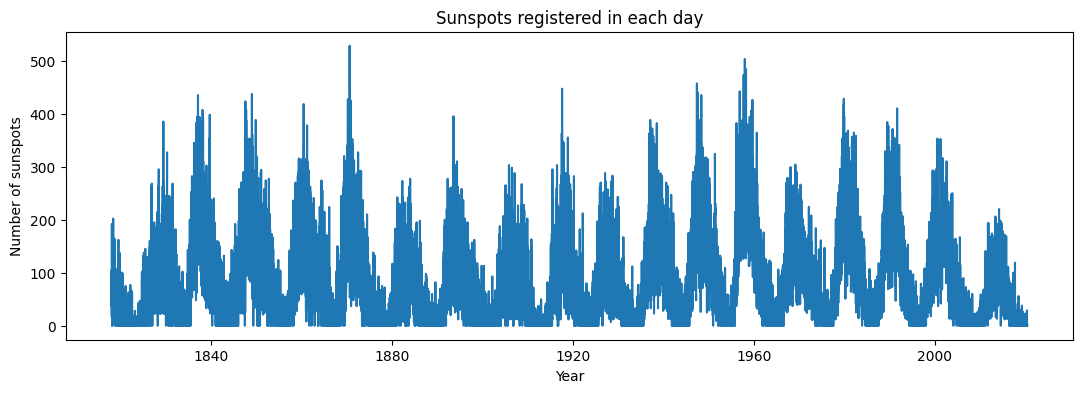

In [ ]:
df3 = pd.read_csv(
    "/content/sunspot_dataset_without_missing_values.tsf",
    sep="\t",
    header=None,
    skiprows=15
)

series_raw = df3.iloc[0, 0]

parts = series_raw.split(":")
valuesstr = parts[2]
values = valuesstr.split(",")
values = pd.to_numeric(values)

# converte a lista para a estrutura Series
y3 = pd.Series(values)

# ordena os valores por data a partir de 01/01/1969
y3.index = pd.date_range(
    start="1818-01-08",
    periods=len(y3),
    freq="D"
)

print(f'Series size: {len(y3)}')
plt.figure(figsize=(13,4))
plt.plot(y3)
plt.title("Sunspots registered in each day")
plt.xlabel("Year")
plt.ylabel("Number of sunspots")
plt.show()

4) Traffic Weekly

Series size: 104


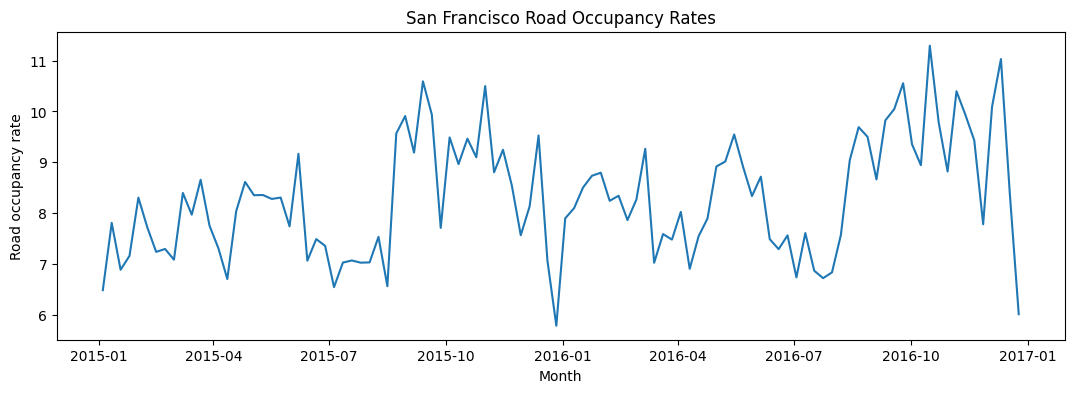

In [ ]:
df4 = pd.read_csv(
    "/content/traffic_weekly_dataset.tsf",
    sep="\t",
    header=None,
    skiprows=17
)

series_raw = df4.iloc[0, 0]

parts = series_raw.split(":")
valuesstr = parts[2]
values = valuesstr.split(",")
values = pd.to_numeric(values)

# converte a lista para a estrutura Series
y4 = pd.Series(values)

# ordena os valores por data a partir de 01/01/1969
y4.index = pd.date_range(
    start="2015-01-01",
    periods=len(y4),
    freq="W"
)

print(f'Series size: {len(y4)}')
plt.figure(figsize=(13,4))
plt.plot(y4)
plt.title("San Francisco Road Occupancy Rates")
plt.xlabel("Month")
plt.ylabel("Road occupancy rate")
plt.show()

5) Tourism Monthly

Series size: 187


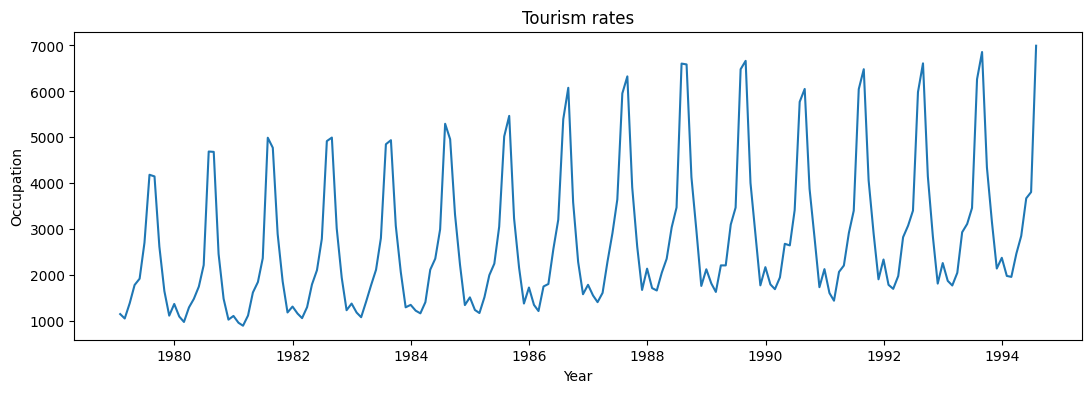

In [ ]:
df5 = pd.read_csv(
    "/content/tourism_monthly_dataset.tsf",
    sep="\t",
    header=None,
    skiprows=15
)

series_raw = df5.iloc[0, 0]

parts = series_raw.split(":")
valuesstr = parts[2]
values = valuesstr.split(",")
values = pd.to_numeric(values)

# converte a lista para a estrutura Series
y5 = pd.Series(values)

# ordena os valores por data a partir de 01/01/1969
y5.index = pd.date_range(
    start="1979-01-01",
    periods=len(y5),
    freq="ME"
)

print(f'Series size: {len(y5)}')
plt.figure(figsize=(13,4))
plt.plot(y5)
plt.title("Tourism rates")
plt.xlabel("Year")
plt.ylabel("Occupation")
plt.show()

Para cada dataset, definimos um valor para os parâmetros context_length e prediction_length. Estes foram determinados tendo em vista as frequências e sazonalidades de cada série.


*   CONTEXT LENGTH representa o tamanho das janelas de entrada, ou seja, quantos valores o modelo utiliza para fazer previsões;
*   FORECASTING HORIZON (ou PREDICTION LENGTH) representa o tamanho da sequência de saída, ou seja, quantos pontos à frente o modelo irá prever.


In [ ]:
datasets = {
    "US Births": y1,
    "Saugeen River Flow": y2,
    "Sunspot": y3,
    "Traffic Weekly": y4,
    "Tourism Monthly": y5
}

datasets_parameters = {
    # analisa 365 valores para prever 30
    # série de sazonalidade anual e 7305 valores no total
    "US Births": {"context_length": 365, "prediction_length": 30},
    # analisa 365 valores para prever 30
    # série de sazonalidade anual e 23741 valores no total
    "Saugeen River Flow": {"context_length": 365, "prediction_length": 30},
    # analisa 365*4 valores para prever 180
    # série de mais de 200 anos com 73924 valores
    "Sunspot": {"context_length": 365*4, "prediction_length": 180},
    # analisa 56 (8 semanas) valores para prever 7
    # série ruidosa, de poucas observações e 104 valores no total
    "Traffic Weekly": {"context_length": 7*8, "prediction_length": 7},
    # analisa 24 valores para prever 6
    # série mensal, de poucas observações e 187 valores no total
    "Tourism Monthly": {"context_length": 24, "prediction_length": 6},

}

Aqui definimos janelas que irão separar os dados das séries temporais em diversas amostras de treino e teste.

In [ ]:
def create_windows(series, context_length, prediction_length):
    x, y = [], []

    # define o "passo" entre as janelas, para otimizar o treinamento
    # de sets muito grandes, sem perder a precisão em sets pequenos
    if (len(series) > 10000 and len(series) < 20000):
      stride = 5
    elif (len(series) < 10000):
      stride = 1
    else:
      stride = 10

    for i in range(0, len(series) - context_length - prediction_length, stride):
        # guarda os dados de uma posição i até i + context_lenght,
        # ou seja, o tamanho da janela de entrada
        x.append(series[i:i+context_length])
        # guarda os dados de uma posição i + context_lenght até a posição ,
        # i+context_length+prediction_length, ou seja, o tamanho da sequência
        # de saída
        y.append(series[i+context_length:i+context_length+prediction_length])
    # retorna um array com todas as janelas de entrada e um array com todas
    # as janelas de saída
    return np.array(x), np.array(y)


Em seguida, definimos um método que avalie a acurácia os resultados das previsões do modelo para cada série segundo as seguintes métricas de avaliação:

1) MAE (mean absolute error)
2) RMSE (root mean squared error)
3) SMAPE (symmetric mean absolute percentage error)

OBS: Sobre o SMAPE - este pode ser definido como uma versão "mais equilibrada" do MAPE (Mean Absolute Percentage Error), sendo útil para dados com valores zero ou grandes variações, que é o caso do dataset Sunspot.

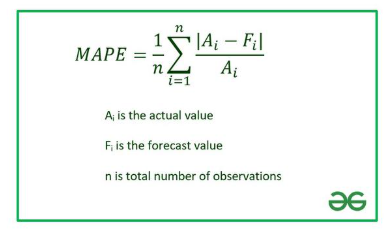

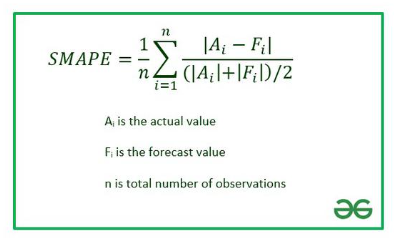

In [ ]:
def evaluate_model(y_test, y_pred):
  mae = MeanAbsoluteError()
  maeV = mae(y_test, y_pred)
  mse = MeanSquaredError()
  mseV = mse(y_test, y_pred)
  rmse = mseV**0.5
  smape = MeanAbsolutePercentageError(symmetric=True)
  smapeV = smape(y_test, y_pred)
  return {"MAE": maeV, "RMSE": rmse, "SMAPE": smapeV}

O modelo escolhido para realizar a previsão foi o **PatchTSMixer**, definido como:

> "uma arquitetura neural leve, composta exclusivamente por módulos de multi layer perceptrons (MLPs), projetada para previsão multivariada e aprendizado de representações em séries temporais segmentadas em patches".

Na seguinte função, treinaremos o modelo.



In [ ]:
def model_config(context_length, prediction_length):
    # configurando o modelo
    config = PatchTSMixerConfig(
        context_length= int(context_length),
        prediction_length= int(prediction_length),
        # patches são "blocos" menores em que se divide a janela de entrada
        # definimos como
        patch_length=8,
        # stride define o passo entre patches consecutivos.
        patch_stride=4,
        # número de camadas do modelo
        num_layers=3,
        # valor da taxa de dropout
        dropout=0.2
    )
    model = PatchTSMixerForPrediction(config)
    return model

def model_train(model, x_train, y_train):
    epochs = 15
    # otimizador usado - Adam
    optimizer = torch.optim.Adam(model.parameters())
    # métrica usada - MSE
    loss_fn = torch.nn.MSELoss()

    model.train()
    for epoch in range(epochs):
        # convertemos os arrays x_train e y_train em tensores

        # unsqueeze adiciona uma dimensão ao tensor de x_train
        # tensores de séries univariadas só tem 1dim
        x_train_tensor = torch.tensor(x_train, dtype=torch.float).unsqueeze(-1)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float).unsqueeze(-1)

        modeloutput = model(x_train_tensor)
        # calcula a perda do modelo segundo a métrica MSE
        loss = loss_fn(modeloutput.prediction_outputs, y_train_tensor)

        # atualiza os gradientes
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

    return model

Em seguida, treinaremos o modelo segundo os parâmetros de cada série.

In [ ]:
results = {}
predictions = {}
realdata = {}

for name, series in datasets.items():
    # definindo as janelas de cada serie segundo os valores definidos
    values = datasets_parameters[name]
    x, y = create_windows(series, values["context_length"], values["prediction_length"])
    # separando os dados em:
    # x_train e y_train - dados usados para treinar o modelo
    # x_test e y_test - dados usados para avaliar o modelo
    x_train, x_test, y_train, y_test = temporal_train_test_split(x, y, test_size=0.2)

    # treinando o modelo usando os parâmetros de cada série
    print(f"\nTraining Model PatchTSMixer for {name}")
    modelsetup = model_config(values["context_length"], values["prediction_length"])
    model = model_train(modelsetup, x_train, y_train)

    # gerando as previsões do modelo
    x_test_tensor = torch.tensor(x_test, dtype=torch.float).unsqueeze(-1)
    model.eval()
    with torch.no_grad():
        preds = model(x_test_tensor).prediction_outputs.numpy()

    predictions[name] = preds
    realdata[name] = y_test

    # calculando o valor das métricas de acurácia analisadas para
    # a performance do modelo em cada série
    metrics = evaluate_model(y_test.flatten(), preds.flatten())
    results[name] = metrics


Training Model PatchTSMixer for US Births
Epoch 0 | Loss: 835693.2500
Epoch 1 | Loss: 694507.1875
Epoch 2 | Loss: 576172.5000
Epoch 3 | Loss: 476399.3750
Epoch 4 | Loss: 396498.9062
Epoch 5 | Loss: 334373.6250
Epoch 6 | Loss: 291370.7812
Epoch 7 | Loss: 262303.5312
Epoch 8 | Loss: 246428.8594
Epoch 9 | Loss: 241189.7344
Epoch 10 | Loss: 240015.3281
Epoch 11 | Loss: 241607.2656
Epoch 12 | Loss: 242218.0312
Epoch 13 | Loss: 240494.5781
Epoch 14 | Loss: 237583.9375

Training Model PatchTSMixer for Saugeen River Flow
Epoch 0 | Loss: 1693.6704
Epoch 1 | Loss: 1597.9307
Epoch 2 | Loss: 1530.2013
Epoch 3 | Loss: 1464.3220
Epoch 4 | Loss: 1412.6565
Epoch 5 | Loss: 1372.1187
Epoch 6 | Loss: 1333.0574
Epoch 7 | Loss: 1304.3997
Epoch 8 | Loss: 1283.4775
Epoch 9 | Loss: 1266.4113
Epoch 10 | Loss: 1245.6354
Epoch 11 | Loss: 1235.9731
Epoch 12 | Loss: 1225.0127
Epoch 13 | Loss: 1210.4030
Epoch 14 | Loss: 1192.7225

Training Model PatchTSMixer for Sunspot
Epoch 0 | Loss: 6780.9751
Epoch 1 | Loss: 41

Assim, podemos analisar a performance do modelo para cada série com base em algumas métricas de avaliação:

In [ ]:
results_df = pd.DataFrame(results).T
print(results_df)

                            MAE         RMSE     SMAPE
US Births            378.898292   526.082277  0.037546
Saugeen River Flow    20.538886    37.508672  0.587303
Sunspot               34.211553    47.374171  0.737187
Traffic Weekly         1.476801     1.716132  0.160322
Tourism Monthly     1132.394202  1414.247801  0.341724


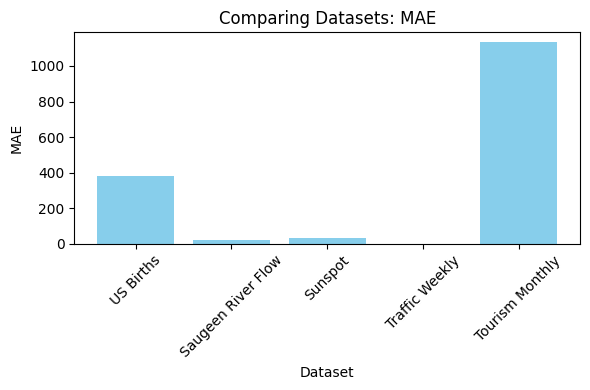

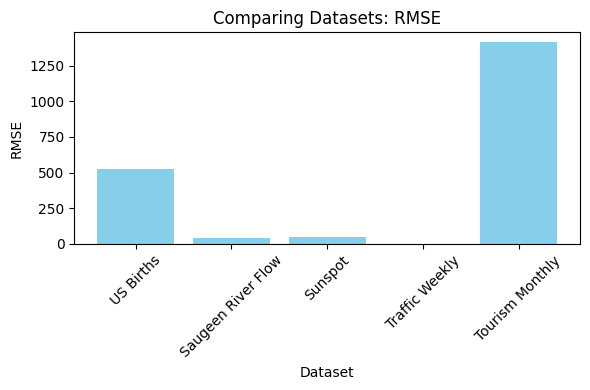

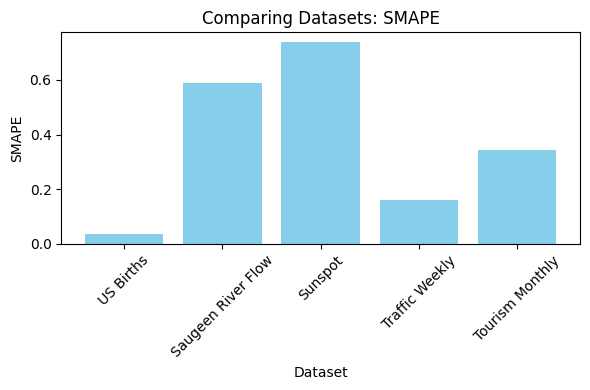

In [ ]:
results_df = pd.DataFrame(results).T

metrics = ["MAE", "RMSE", "SMAPE"]

for metric in metrics:
    plt.figure(figsize=(6,4))
    plt.bar(results_df.index, results_df[metric], color='skyblue')
    plt.title(f'Comparing Datasets: {metric}')
    plt.xlabel('Dataset')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

No que diz respeito às métricas MAE e RMSE, observamos uma proporção parecida entre os valores observados nos erros das previsões realizadas nas séries. Todavia, é notório que o erro observado com a métrica RMSE para Tourism Monthly é consideravelmente maior.

No que diz respeito à série Sunspot obtivemos uma valor baixo nas métricas MAE e RMSE, mas um valor alto na métrica SMAPE, o que se deu, provavelmente, pela grande quantidade de zeros encontrados no dataset. O mesmo pode ser observado nos resultados obtidos na predição dos valores da série Saugeen River Flow.

A série Traffic Weekly, apesar de bastante ruidosa, obteve um erro menor. Todavia, podemos observar no gráfico abaixo uma distinção considerável entre os valores reais e os valores obtidos pela previsão do modelo.

Na série Tourism Monthly, apesar de observarmos valores mais homogêneos, com picos equilibrados e curvas mais consistentes, o resultado do modelo não foi tão satisfatório.



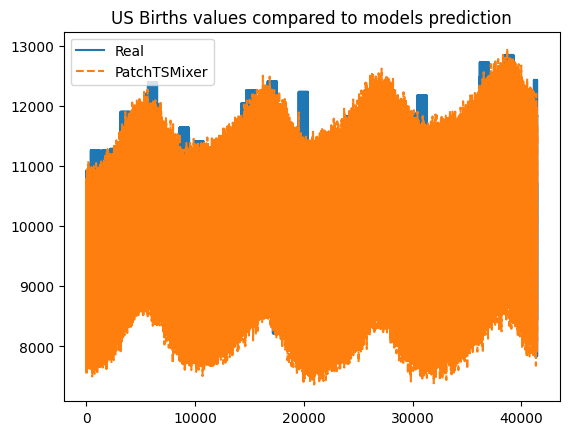

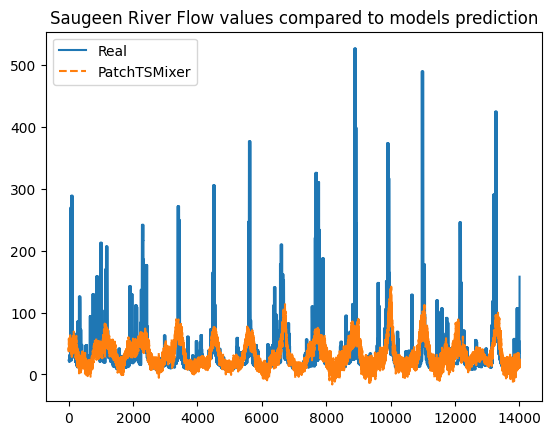

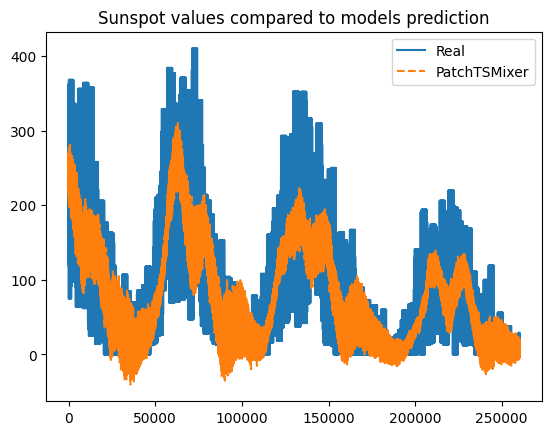

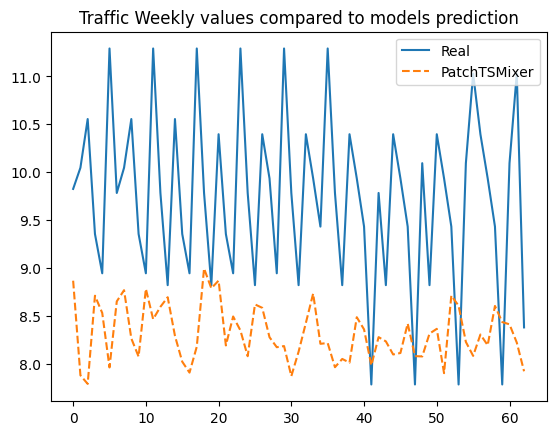

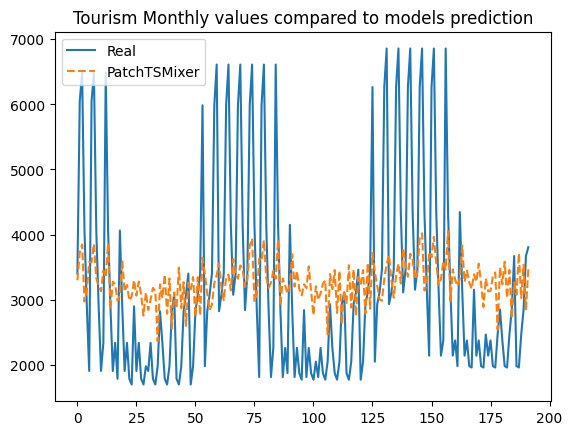

In [ ]:
for name in predictions:
  y_test = realdata[name].flatten()
  y_pred = predictions[name].flatten()

  plt.title(f'{name} values compared to models prediction')
  plt.plot(y_test, label="Real")
  plt.plot(y_pred, "--", label="PatchTSMixer")
  plt.legend()
  plt.show()


Analisando os gráficos acima, que exibem as diferenças entre os valores reais esperados e os resultados do modelo, podemos ter uma interpretação distinta.

Traffic Weekly, apesar do erro baixo, obteve um resultado que quase não se aproxima do esperado com valores muito abaixo do horizonte. Em contrapartida, é importante destacar que esta série conta com menos de 200 valores, o que afeta a qualidade da predição.

Na previsão das séries Saugeen River Flow e Tourism Monthly, a curva da previsão se manteve parecida em alguns pontos mas não acompanhou alguns picos. Na previsão da série US Births, também obtivemos um resultado que se aproximou do horizonte, mas com maior ruído.

Os valores obtidos na previsão do dataset Sunspot foram, visualmente, os que mais se adequaram ao esperado, acompanhando os crescimentos e decrescimentos do horizonte. Em compensação, a série Sunspot é muito maior do que as outras, contando com quase 74 mil observações.